In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import datetime
import pandas as pd
import numpy as np
from gnomepy import Strategy, LatencyModel, SchemaBase, Order, OrderExecutionReport
from gnomepy.research.oms import LimitOrderOMS
from gnomepy.research.signals.basic_mm import BasicMMSignal, BasicMMRecorder, RealizedVolatilityModel
from gnomepy.backtest import (
    Backtest,
    MBPSimulatedExchange,
    StaticLatency,
    RiskAverseQueueModel,
    ProbabilisticQueueModel,
    StaticFeeModel
)
from gnomepy.data.types import SchemaType
from gnomepy.data.cached_client import CachedMarketDataClient
from gnomepy.registry.api import RegistryClient
from gnomepy.backtest.recorder import Recorder

# Configuration
START_DATETIME = datetime.datetime(2026, 1, 15, 12, 0)
END_DATETIME = datetime.datetime(2026, 1, 18, 12, 0)
SCHEMA_TYPE = SchemaType.MBP_10
NOTIONAL = 100_000
LISTING_IDS = [1]

# BasicMM parameters (for RealizedVolatilityModel baseline)
# NOTE: vol_threshold_bps is in per-tick bps (models now return per-tick vol)
BASIC_MM_PARAMS = {
    'trade_frequency': 1,
    'gamma': 131501,
    'order_arrival_rate': 2838,
    'volatility_window': 50,
    'volatility_half_life': 0.5,
    'max_inventory': 1.0,
    'max_spread_ticks': None,
    'min_volatility': 1e-5,
    'min_spread_bps': 0.1,
    'vol_threshold_bps': 0.67,
}

# Realized vol model parameters
VOL_MODEL_PARAMS = {
    'window': 100,
    'horizon': 20,
}

STRATEGY_LATENCY = StaticLatency(1_000_000)
NETWORK_LATENCY = StaticLatency(50_000_000)
ORDER_PROCESSING_LATENCY = StaticLatency(20_000_000)

In [3]:
market_data_client = CachedMarketDataClient(
    bucket="gnome-market-data-dev",
    aws_profile_name="AWSAdministratorAccess-443370708724",
)
registry_client = RegistryClient(
    api_key="9WPV7CfeqXa578yVYlxdG3kCPFzACr7YaMU0UVma",
)

In [4]:
listings = []
for listing_id in LISTING_IDS:
    result = registry_client.get_listing(listing_id=listing_id)
    if not result:
        raise ValueError(f"Unable to find listing_id: {listing_id}")
    listings.append(result[0])
    print(f"Loaded: {result[0]}")

listing = listings[0]

Loaded: Listing(listing_id=1, security_id=1, exchange_id=1, exchange_security_id='undefined', exchange_security_symbol='BTC', date_modified='2025-12-23T18:11:06.557Z', date_created='2025-12-23T18:11:06.557Z')


In [5]:
# Create volatility model
vol_model = RealizedVolatilityModel(**VOL_MODEL_PARAMS)

# Create simulated exchange
exchanges = {
    listing.exchange_id: {
        listing.security_id: MBPSimulatedExchange(
            fee_model=StaticFeeModel(taker_fee=0.004, maker_fee=-0.001),
            network_latency=NETWORK_LATENCY,
            order_processing_latency=ORDER_PROCESSING_LATENCY,
            queue_model=RiskAverseQueueModel()
        )
    }
}

# Create signal recorder
signal_recorder = BasicMMRecorder(listing_ids=LISTING_IDS)

# Create signal
basic_mm_signal = BasicMMSignal(
    listing=listing,
    volatility_model=vol_model,
    data_schema_type=SCHEMA_TYPE,
    **BASIC_MM_PARAMS,
    recorder=signal_recorder,
)

# Create OMS
oms = LimitOrderOMS(
    signals=[basic_mm_signal],
    notional=NOTIONAL,
    position_aware_sizing=False,
    position_scaling_factor=0.3,
    tick_size=0.01,
    passive_reprice_ticks=3,
)

In [6]:
class OMSStrategy(Strategy):
    """Generic strategy wrapper for OMS-based strategies."""

    def __init__(self, processing_latency: LatencyModel, oms):
        super().__init__(processing_latency)
        self.oms = oms

    def on_market_data(self, timestamp: int, data: SchemaBase, recorder: Recorder | None = None) -> list[Order]:
        return self.oms.on_market_update(timestamp, data, recorder)

    def on_execution_report(self, timestamp: int, execution_report: OrderExecutionReport, recorder: Recorder | None = None):
        self.oms.on_execution_report(timestamp, execution_report, recorder)

strategy = OMSStrategy(processing_latency=STRATEGY_LATENCY, oms=oms)

In [9]:
backtest = Backtest(
    start_datetime=START_DATETIME,
    end_datetime=END_DATETIME,
    listing_ids=LISTING_IDS,
    schema_type=SCHEMA_TYPE,
    strategy=strategy,
    exchanges=exchanges,
    market_data_client=market_data_client,
    registry_client=registry_client
)

print("Preparing data...")
backtest.prepare_data()

print("Executing backtest...")
backtest.fully_execute()
print("Done.")

Preparing data...


2026-01-16 03:22:15.190939034:  |████████████████████████████▊                                                                                                          |  21% [14:49<54:37]
██████████████████▋                                                                                                                      |  14% [03:33<22:28] | 2026-01-15 21:50:38.619000: 


Executing backtest...
Done.


Signal positions: {<gnomepy.research.signals.basic_mm.signal.BasicMMSignal object at 0x11412bb60>: {1: -0.7327069999999997}}
Overall positions: {1: -0.7327069999999997}
{'total_records': np.int64(862231), 'market_buffer_usage': {1: np.float64(0.538894375)}, 'intent_buffer_usage': {1: np.float64(0.0)}, 'schema_type': 'mbp-10', 'assets': {1: {'market_record_count': 862231, 'market_timestamp_range': (1768509895681343853, 1768682159891429776), 'market_price_range': (94307.5, 95845.5)}}}


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,6118.207757,-5680.935641,0.00747,455.881809,1.574481,2.207915,-1.076972,0.0,0.0


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades,listing_id
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,6118.207757,-5680.935641,0.00747,455.881809,1.574481,2.207915,-1.076972,85.000683,775.0,1


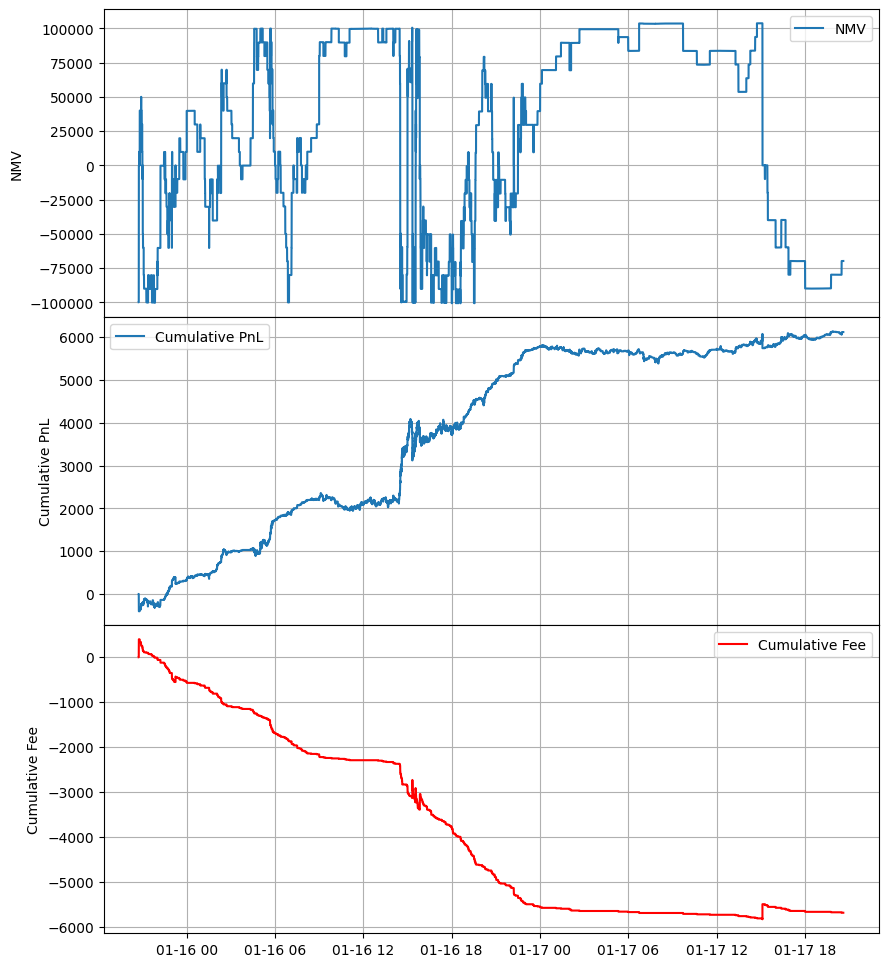

In [10]:
# OMS state
print(f"Signal positions: {oms.signal_positions}")
print(f"Overall positions: {oms.positions}")

from gnomepy.backtest.stats.strategy import StrategyStats

print(backtest.recorder.get_summary_stats())

strat_sts = StrategyStats(
    {
        listing_id: backtest.recorder.get_record(listing_id).stats()
        for listing_id in LISTING_IDS
    },
)

display(strat_sts.summary())
display(strat_sts.listing_summary())
strat_sts.plot()

,mid_price,inventory,realized_vol,predicted_vol_bps,optimal_bid,optimal_ask,reservation_price,best_bid,best_ask,bid_confidence,ask_confidence,circuit_breaker_active,spread
timestamp,,,,,,,,,,,,,
2026-01-15 20:45:08.881774428,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:09.380811859,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:09.481040170,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:09.882042880,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.282604326,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.282604326,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.580799395,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.880769099,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0
2026-01-15 20:45:10.880769099,95240.5,0.0,0.000011,0.111063,95240.023798,95240.976202,95240.5,95240.0,95241.0,0.1,0.1,0,1.0


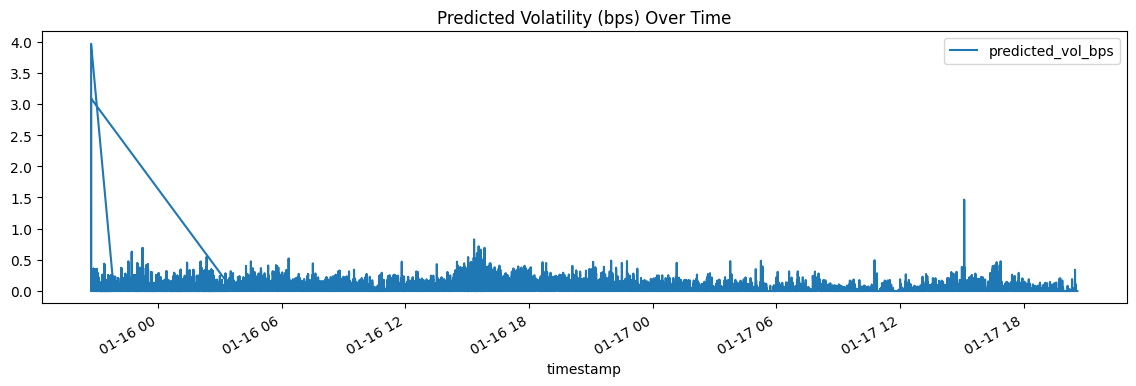

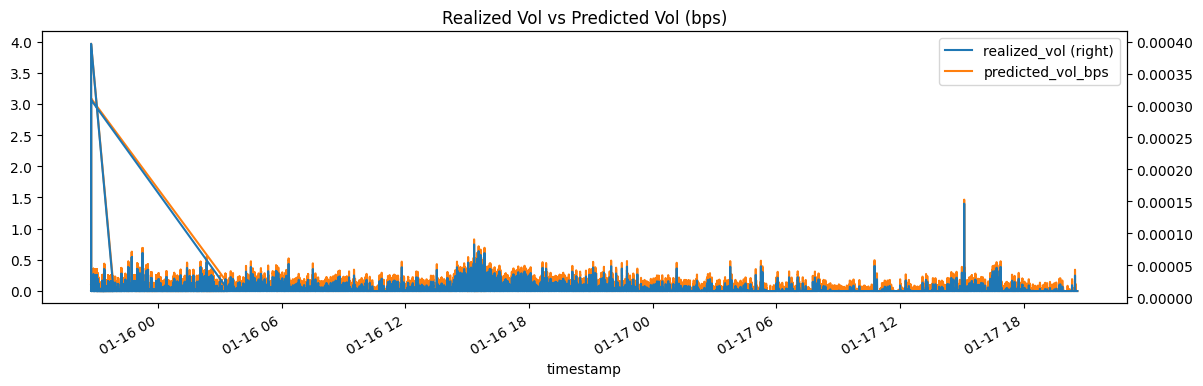

In [11]:
# Model values analysis
if basic_mm_signal.recorder is not None:
    df = basic_mm_signal.recorder.get_record(listing.listing_id).df
    display(df.head(20))

    # Plot predicted volatility over time
    df[['predicted_vol_bps']].plot(title='Predicted Volatility (bps) Over Time', figsize=(14, 4))

    # Plot realized vol vs predicted vol
    df[['realized_vol', 'predicted_vol_bps']].plot(
        title='Realized Vol vs Predicted Vol (bps)',
        secondary_y='realized_vol',
        figsize=(14, 4)
    )

Circuit breaker fired: 751/998867 ticks (0.08%)


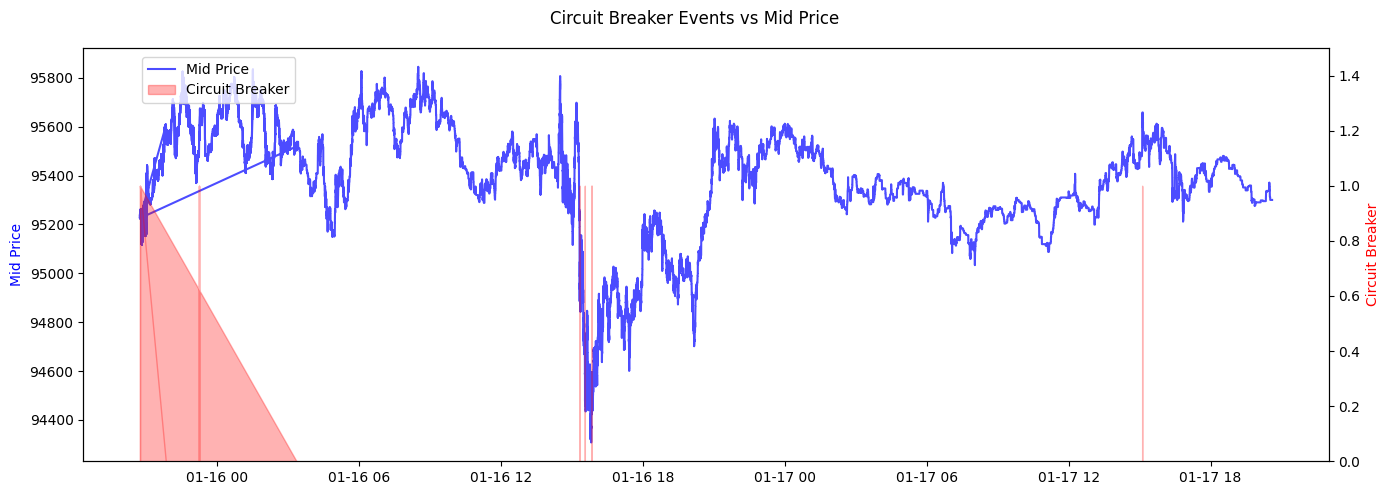

In [12]:
# Circuit breaker analysis
if basic_mm_signal.recorder is not None:
    df = basic_mm_signal.recorder.get_record(listing.listing_id).df

    cb_active = df['circuit_breaker_active'].astype(bool)
    total_ticks = len(df)
    cb_ticks = cb_active.sum()
    print(f"Circuit breaker fired: {cb_ticks}/{total_ticks} ticks ({cb_ticks/total_ticks*100:.2f}%)")

    # Plot circuit breaker timeline against mid price
    import matplotlib.pyplot as plt

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(df.index, df['mid_price'], color='blue', alpha=0.7, label='Mid Price')
    ax1.set_ylabel('Mid Price', color='blue')

    ax2 = ax1.twinx()
    ax2.fill_between(df.index, 0, cb_active.astype(int), alpha=0.3, color='red', label='Circuit Breaker')
    ax2.set_ylabel('Circuit Breaker', color='red')
    ax2.set_ylim(0, 1.5)

    fig.suptitle('Circuit Breaker Events vs Mid Price')
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()

,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,6118.207757,-5680.935641,0.00747,455.881809,1.574481,2.207915,-1.076972,85.000683,775.0


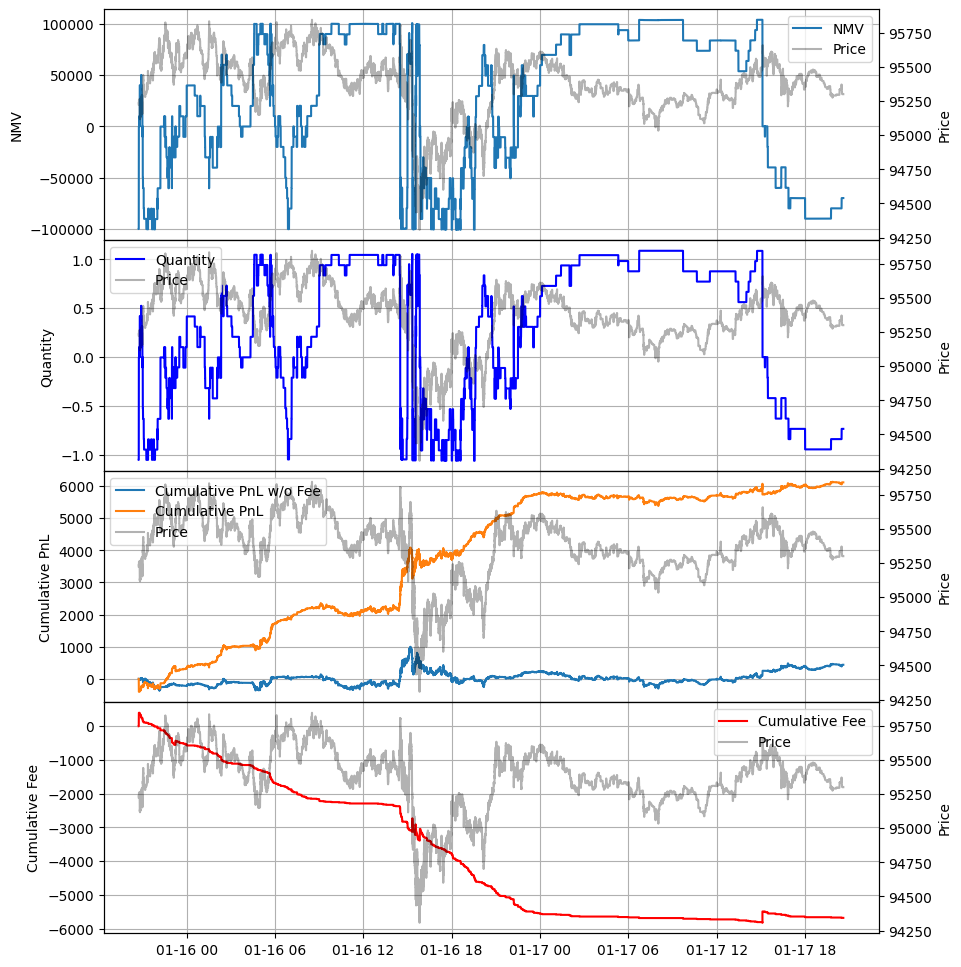

In [13]:
listing_stats = backtest.recorder.get_record(1).stats()
display(listing_stats.summary())
listing_stats.plot()

---
## LGBM Volatility Model Training

Train an LGBM regression model to predict forward absolute price movement in bps.
Uses the same 44 features as the directional model, but with regression objective
and absolute return labels.

### Training config

In [14]:
from gnomepy.research.signals.basic_mm.lgbm_volatility import LGBMVolatilityTrainer, LGBMVolatilityModel
from gnomepy.research.signals.basic_mm.lgbm_volatility.features import VOL_FEATURE_NAMES
from gnomepy.research.signals.lgbm_directional.registry import ModelRegistry
import lightgbm as lgb

# Training date range (should precede or overlap backtest period)
TRAIN_START = datetime.datetime(2026, 1, 15, 12, 0)
TRAIN_END   = datetime.datetime(2026, 1, 17, 12, 0)

# Volatility model training parameters
VOL_HORIZON = 20          # ticks to look ahead for label
TRAIN_WINDOW = 50000      # rows per training fold
VAL_WINDOW   = 10000      # rows per validation fold

VOL_REGISTRY_DIR = "./vol_models"

### Load data & extract features

Loading data for listing 1 ...
  Loaded 759308 rows
  759238 usable samples
  Label stats (log1p space): mean=0.0596, median=0.0000, std=0.1574
  Label stats (per-tick bps): mean=0.08, median=0.00, std=0.43

Features shape: (759238, 30)
Feature names: ['volatility_5', 'volatility_10', 'volatility_20', 'volatility_50', 'realized_var_5', 'realized_var_10', 'realized_var_20', 'realized_var_50', 'parkinson_10', 'parkinson_20', 'parkinson_50', 'vol_ratio_5_20', 'vol_ratio_5_50', 'vol_of_vol_20', 'return_autocorr_10', 'return_autocorr_20', 'abs_return_sum_10', 'abs_return_sum_20', 'return_kurtosis_20', 'spread_bps', 'spread_mean_20', 'spread_std_10', 'tob_imbalance', 'depth_ratio', 'total_bid_depth', 'total_ask_depth', 'depth_change_5', 'microprice_deviation', 'bid_withdrawal_5', 'ask_withdrawal_5']

Label distribution (log1p space):


count    759238.000000
mean          0.059634
std           0.157385
min           0.000000
25%           0.000000
50%           0.000000
75%           0.055780
max           3.186825
dtype: float64

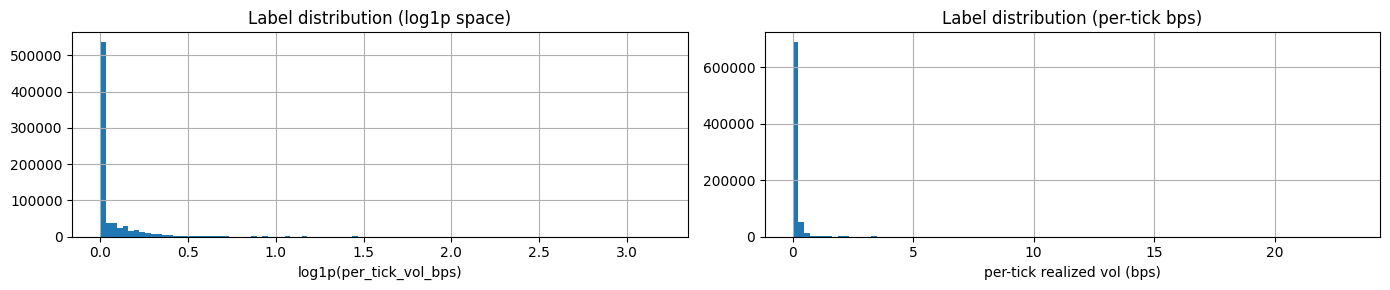

In [15]:
vol_trainer = LGBMVolatilityTrainer(
    listing_id=LISTING_IDS[0],
    start_datetime=TRAIN_START,
    end_datetime=TRAIN_END,
    schema_type=SCHEMA_TYPE,
    horizon=VOL_HORIZON,
    market_data_client=market_data_client,
    registry_client=registry_client,
)

X_vol, y_vol = vol_trainer.prepare()
print(f"\nFeatures shape: {X_vol.shape}")
print(f"Feature names: {list(X_vol.columns)}")
print(f"\nLabel distribution (log1p space):")
display(y_vol.describe())

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
y_vol.hist(bins=100, ax=axes[0])
axes[0].set_title("Label distribution (log1p space)")
axes[0].set_xlabel("log1p(per_tick_vol_bps)")

y_vol_bps = np.expm1(y_vol)
y_vol_bps.hist(bins=100, ax=axes[1])
axes[1].set_title("Label distribution (per-tick bps)")
axes[1].set_xlabel("per-tick realized vol (bps)")
plt.tight_layout()
plt.show()

### Walk-forward validation (default params)

  759238 usable samples
  Label stats (log1p space): mean=0.0596, median=0.0000, std=0.1574
  Label stats (per-tick bps): mean=0.08, median=0.00, std=0.43

=== Walk-Forward Report ===

Fold 0: {'mae': 0.09448144258002553, 'rmse': 0.3018297014461938, 'median_ae': 0.037329248449524816, 'correlation': 0.12214065743658918}
Fold 1: {'mae': 0.06841676518525242, 'rmse': 0.2071773791332345, 'median_ae': 0.03195264668277028, 'correlation': 0.14470170361950208}
Fold 2: {'mae': 0.09010461821601289, 'rmse': 0.24431868642999585, 'median_ae': 0.03482713431251404, 'correlation': 0.08776325204427528}
Fold 3: {'mae': 0.09493305916972482, 'rmse': 0.34116376116990843, 'median_ae': 0.033840330464568046, 'correlation': 0.13576820382301924}
Fold 4: {'mae': 0.09338015598594462, 'rmse': 0.35189565031527115, 'median_ae': 0.03772630536703159, 'correlation': 0.03691573841824406}
Fold 5: {'mae': 0.08703640424037895, 'rmse': 0.429756134803397, 'median_ae': 0.027173271387176866, 'correlation': 0.034736016900272046}

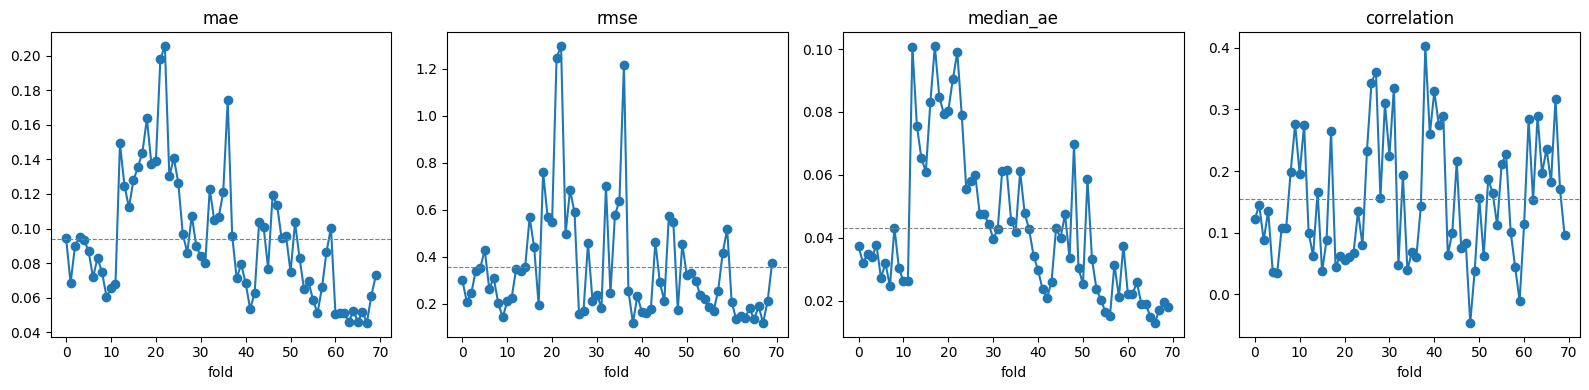

,mae,rmse,median_ae,correlation
fold,,,,
0,0.094481,0.301830,0.037329,0.122141
1,0.068417,0.207177,0.031953,0.144702
2,0.090105,0.244319,0.034827,0.087763
3,0.094933,0.341164,0.033840,0.135768
4,0.093380,0.351896,0.037726,0.036916
...,...,...,...,...
65,0.046005,0.134108,0.014964,0.235980
66,0.051929,0.189231,0.012939,0.181877
67,0.045413,0.118325,0.017125,0.317202


In [16]:
default_vol_params = {
    "num_leaves": 31,
    "max_depth": 6,
    "learning_rate": 0.05,
    "min_child_samples": 100,
    "feature_fraction": 0.8,
}

vol_fold_results = vol_trainer.walk_forward_validate(
    params=default_vol_params,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
)

vol_report = vol_trainer.report(vol_fold_results)

# Plot per-fold metrics
import matplotlib.pyplot as plt

vol_metrics_df = pd.DataFrame([fr.metrics for fr in vol_fold_results])
vol_metrics_df.index.name = "fold"

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(["mae", "rmse", "median_ae", "correlation"]):
    vol_metrics_df[col].plot(ax=axes[i], marker="o", title=col)
    axes[i].axhline(vol_metrics_df[col].mean(), ls="--", color="grey", lw=0.8)
plt.tight_layout()
plt.show()
display(vol_metrics_df)

### Hyperparameter tuning (optional)

Uncomment to run random search. Otherwise uses `default_vol_params`.

In [ ]:
from gnomepy.research.signals.basic_mm.lgbm_volatility.trainer import DEFAULT_PARAM_GRID

vol_tuning_result = vol_trainer.tune_hyperparameters(
    param_grid=DEFAULT_PARAM_GRID,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
    n_random=20,
    metric="mae",
)
print(f"\nBest params: {vol_tuning_result.best_params}")
display(pd.DataFrame(vol_tuning_result.all_results).head(10))

### Train final model & register

In [17]:
vol_registry = ModelRegistry(base_dir=VOL_REGISTRY_DIR)

# Use default_vol_params, or vol_tuning_result.best_params if tuning was run
vol_model_lgbm = vol_trainer.train(
    params=default_vol_params,
    register=False,
    registry=vol_registry,
)

print(f"\nRegistered versions:")
display(vol_registry.compare(LISTING_IDS[0]))

  759238 usable samples
  Label stats (log1p space): mean=0.0596, median=0.0000, std=0.1574
  Label stats (per-tick bps): mean=0.08, median=0.00, std=0.43
  759238 usable samples
  Label stats (log1p space): mean=0.0596, median=0.0000, std=0.1574
  Label stats (per-tick bps): mean=0.08, median=0.00, std=0.43

Registered versions:


,created_at,mean_auc,mean_accuracy
version,,,
v1,2026-02-23T05:20:09.741543+00:00,None,None


### Feature importance

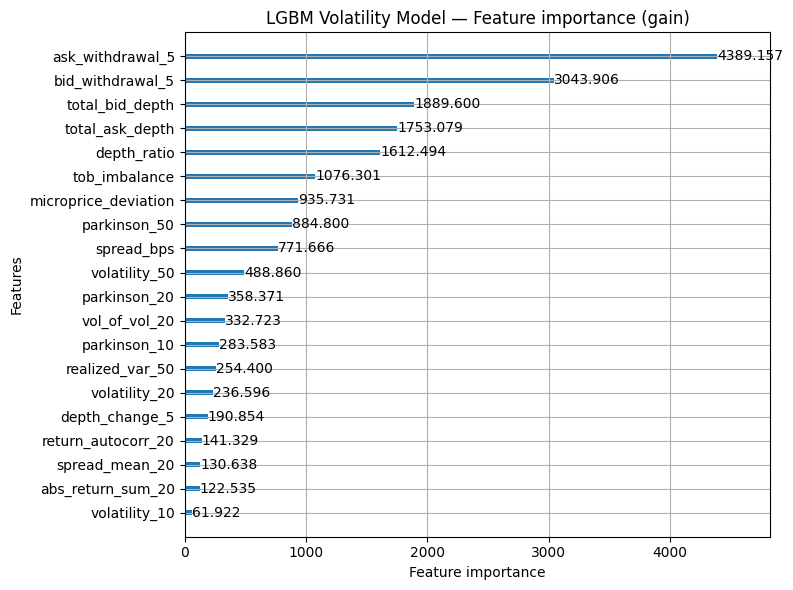

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
lgb.plot_importance(vol_model_lgbm, ax=ax, importance_type="gain", max_num_features=20)
ax.set_title("LGBM Volatility Model — Feature importance (gain)")
plt.tight_layout()
plt.show()

---
## Calibrate BasicMM Parameters (Vol-Model-Aware)

The old `AvellanedaStoikovCalibrator` estimates volatility using rolling std, but
`BasicMMSignal` uses the LGBM model at runtime. Gamma calibrated against rolling std
is inconsistent with the model's actual prediction distribution.

`BasicMMCalibrator` replays the trained vol model over historical data and solves for
gamma/k that produce a user-specified target spread under the model's real predictions.

In [19]:
from gnomepy.research.signals.basic_mm import BasicMMCalibrator

# Load the LGBM vol model we just trained
cal_vol_model = LGBMVolatilityModel(
    registry=vol_registry,
    listing_id=LISTING_IDS[0],
    horizon=VOL_HORIZON,
)

calibrator_mm = BasicMMCalibrator(
    volatility_model=cal_vol_model,
    listing_id=LISTING_IDS[0],
    start_datetime=TRAIN_START,
    end_datetime=TRAIN_END,
    schema_type=SCHEMA_TYPE,
    market_data_client=market_data_client,
    registry_client=registry_client,
)

# Calibrate: target 1.0 bps spread at median vol, ~1% circuit breaker rate
cal_results = calibrator_mm.calibrate(
    target_spread_bps=0.2,
    spread_quantile=0.5,
    cb_activation_rate=0.01,
    stride=10,
    min_volatility=0,   # <-- must match signal's min_volatility
)
calibrator_mm.report(cal_results)

Loading data for listing 1 ...
  Loaded 759,308 rows
  Vol model replay: 75,926 / 75,926 valid predictions (stride=10)
  Order arrival rate (k): 6,681
  Calibrated gamma: 721,287,857,978,050

  BasicMM Calibration Report
Vol Model: LGBMVolatilityModel (horizon=20)
Data: 759,308 ticks (75,926 sampled)

Prediction Distribution (per-tick bps):
  Median: 0.04   Mean: 0.06   P95: 0.18   P99: 0.24

Calibrated Parameters:
  gamma:              721,287,857,978,050
  order_arrival_rate: 6,681
  vol_threshold_bps:  0.24 (P99, ~1% CB rate)

Spread Profile (zero inventory):
  At P25 vol: 0.07 bps    At median vol: 0.20 bps [TARGET=0.20]
  At P75 vol: 0.84 bps    At P95 vol:    3.61 bps

Variance Ratio: 1.01 (OK)



  Vol model replay: 75,926 / 75,926 valid predictions (stride=10)


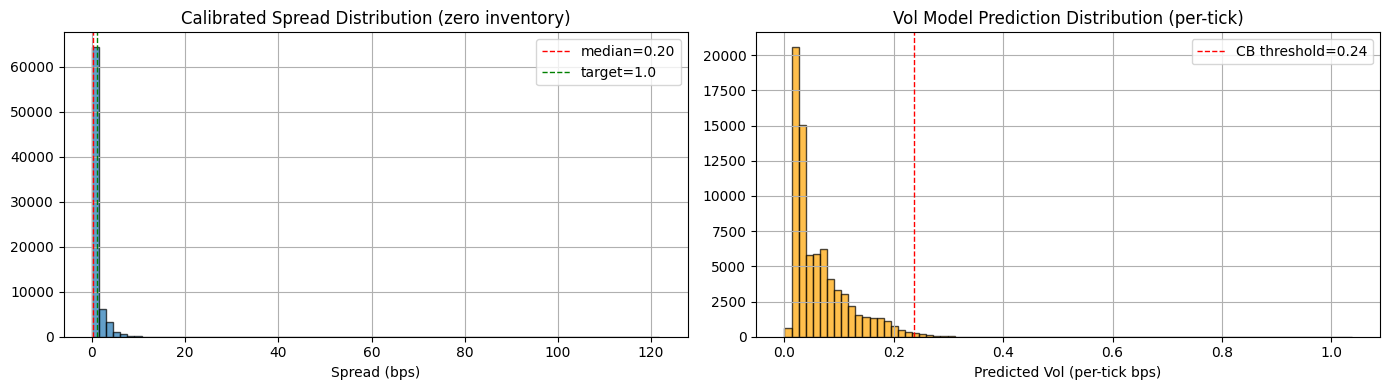

Spread quantiles (bps):


count    75926.000000
mean         0.779321
std          1.457304
min          0.000001
25%          0.068571
50%          0.200000
75%          0.837351
max        121.728081
Name: spread_bps, dtype: float64

In [20]:
# Spread distribution diagnostic — verify median spread hits target
spread_df = calibrator_mm.spread_distribution(
    gamma=cal_results["gamma"],
    k=cal_results["order_arrival_rate"],
    stride=10,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

spread_df["spread_bps"].hist(ax=axes[0], bins=80, alpha=0.7, edgecolor="black")
axes[0].axvline(spread_df["spread_bps"].median(), color="red", ls="--", lw=1,
                label=f"median={spread_df['spread_bps'].median():.2f}")
axes[0].axvline(1.0, color="green", ls="--", lw=1, label="target=1.0")
axes[0].set_xlabel("Spread (bps)")
axes[0].set_title("Calibrated Spread Distribution (zero inventory)")
axes[0].legend()

spread_df["predicted_bps"].hist(ax=axes[1], bins=80, alpha=0.7, edgecolor="black", color="orange")
axes[1].axvline(cal_results["vol_threshold_bps"], color="red", ls="--", lw=1,
                label=f"CB threshold={cal_results['vol_threshold_bps']:.2f}")
axes[1].set_xlabel("Predicted Vol (per-tick bps)")
axes[1].set_title("Vol Model Prediction Distribution (per-tick)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Spread quantiles (bps):")
display(spread_df["spread_bps"].describe())

---
## Backtest with LGBM Volatility Model

Re-run the backtest using the trained `LGBMVolatilityModel` instead of
`RealizedVolatilityModel`. The LGBM model's prediction feeds both the
circuit breaker and the AS sigma parameter.

In [21]:
START_DATETIME = datetime.datetime(2026, 1, 19, 12, 0)
END_DATETIME = datetime.datetime(2026, 1, 24, 12, 0)

# Load LGBM volatility model from registry
lgbm_vol_model = LGBMVolatilityModel(
    registry=vol_registry,
    listing_id=LISTING_IDS[0],
    horizon=VOL_HORIZON,
)
print(f"LGBM vol model: min_lookback={lgbm_vol_model.min_lookback}, horizon={lgbm_vol_model.horizon}")

# Build params from calibration results
CALIBRATED_MM_PARAMS = {
    'trade_frequency': 1,
    'gamma': cal_results['gamma'],
    'order_arrival_rate': cal_results['order_arrival_rate'],
    'volatility_window': 50,
    'volatility_half_life': 0.5,
    'max_inventory': 1.0,
    'max_spread_ticks': None,
    'min_volatility': 0,
    'min_spread_bps': 0,
    'vol_threshold_bps': cal_results['vol_threshold_bps'],
}
print(f"Using calibrated params: gamma={CALIBRATED_MM_PARAMS['gamma']:,.0f}, "
      f"k={CALIBRATED_MM_PARAMS['order_arrival_rate']:,.0f}, "
      f"vol_threshold={CALIBRATED_MM_PARAMS['vol_threshold_bps']:.2f} bps")

# Create new exchange instances (fresh state)
lgbm_exchanges = {
    listing.exchange_id: {
        listing.security_id: MBPSimulatedExchange(
            fee_model=StaticFeeModel(taker_fee=0.004, maker_fee=-0.001),
            network_latency=NETWORK_LATENCY,
            order_processing_latency=ORDER_PROCESSING_LATENCY,
            queue_model=RiskAverseQueueModel(), #ProbabilisticQueueModel(cancel_ahead_probability=0.5)
        )
    }
}

lgbm_signal_recorder = BasicMMRecorder(listing_ids=LISTING_IDS)

lgbm_mm_signal = BasicMMSignal(
    listing=listing,
    volatility_model=lgbm_vol_model,
    data_schema_type=SCHEMA_TYPE,
    **CALIBRATED_MM_PARAMS,
    recorder=lgbm_signal_recorder,
)

lgbm_oms = LimitOrderOMS(
    signals=[lgbm_mm_signal],
    notional=NOTIONAL,
    position_aware_sizing=False,
    position_scaling_factor=0.3,
    tick_size=0.1,
    passive_reprice_ticks=3,
)

lgbm_strategy = OMSStrategy(processing_latency=STRATEGY_LATENCY, oms=lgbm_oms)
print("LGBM backtest components created.")

LGBM vol model: min_lookback=52, horizon=20
Using calibrated params: gamma=721,287,857,978,050, k=6,681, vol_threshold=0.24 bps
LGBM backtest components created.


In [22]:
lgbm_backtest = Backtest(
    start_datetime=START_DATETIME,
    end_datetime=END_DATETIME,
    listing_ids=LISTING_IDS,
    schema_type=SCHEMA_TYPE,
    strategy=lgbm_strategy,
    exchanges=lgbm_exchanges,
    market_data_client=market_data_client,
    registry_client=registry_client,
)

print("Preparing data...")
lgbm_backtest.prepare_data()

print("Executing LGBM backtest...")
lgbm_backtest.fully_execute()
print("Done.")

Preparing data...
Executing LGBM backtest...
Done.


### LGBM backtest results

Signal positions: {<gnomepy.research.signals.basic_mm.signal.BasicMMSignal object at 0x1439b8f50>: {1: 0.1487020000000277}}
Overall positions: {1: 0.1487020000000277}


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-19 12:00:03.180841055,2026-01-22 00:28:59.890919786,17157.440152,-63001.842527,0.00191,1001.783464,11.999479,8.2118,-0.272332,0.0,0.0


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades,listing_id
0,2026-01-19 12:00:03.180841055,2026-01-22 00:28:59.890919786,17157.440152,-63001.842527,0.00191,1001.783464,11.999479,8.2118,-0.272332,4744.506396,28554.0,1


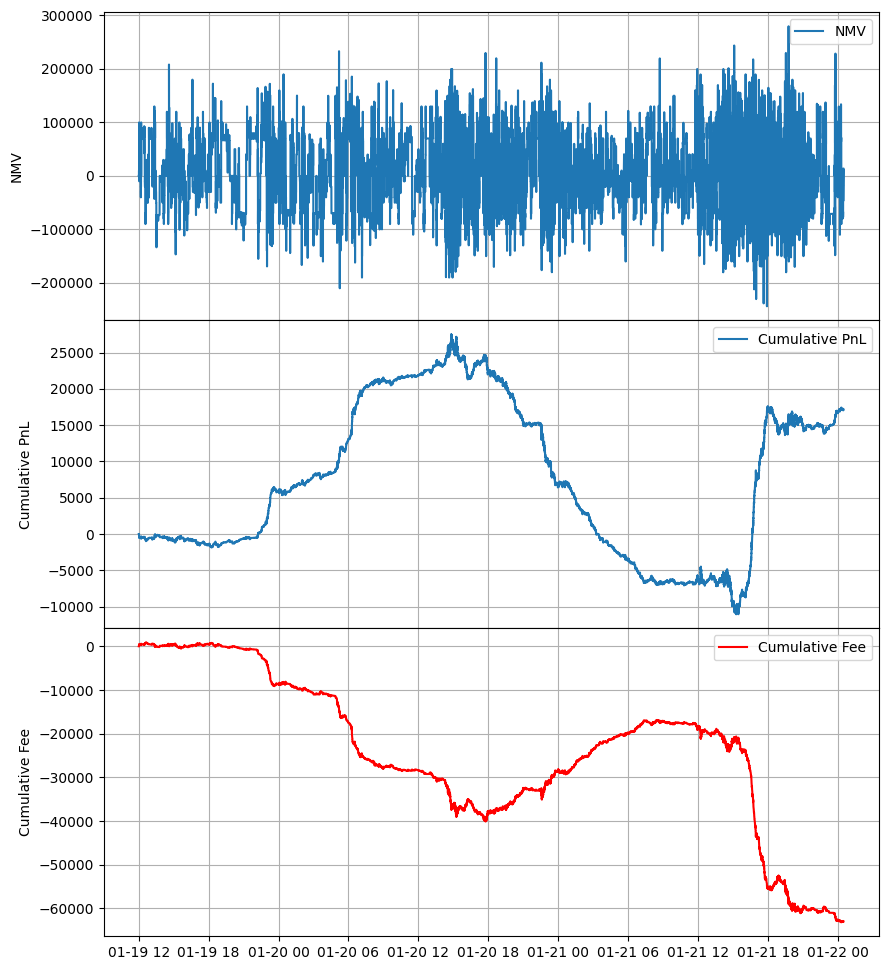

In [23]:
print(f"Signal positions: {lgbm_oms.signal_positions}")
print(f"Overall positions: {lgbm_oms.positions}")

lgbm_strat_sts = StrategyStats(
    {
        listing_id: lgbm_backtest.recorder.get_record(listing_id).stats()
        for listing_id in LISTING_IDS
    },
)

display(lgbm_strat_sts.summary())
display(lgbm_strat_sts.listing_summary())
lgbm_strat_sts.plot()

,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-19 12:00:03.180841055,2026-01-22 00:28:59.890919786,17157.440152,-63001.842527,0.00191,1001.783464,11.999479,8.2118,-0.272332,4744.506396,28554.0


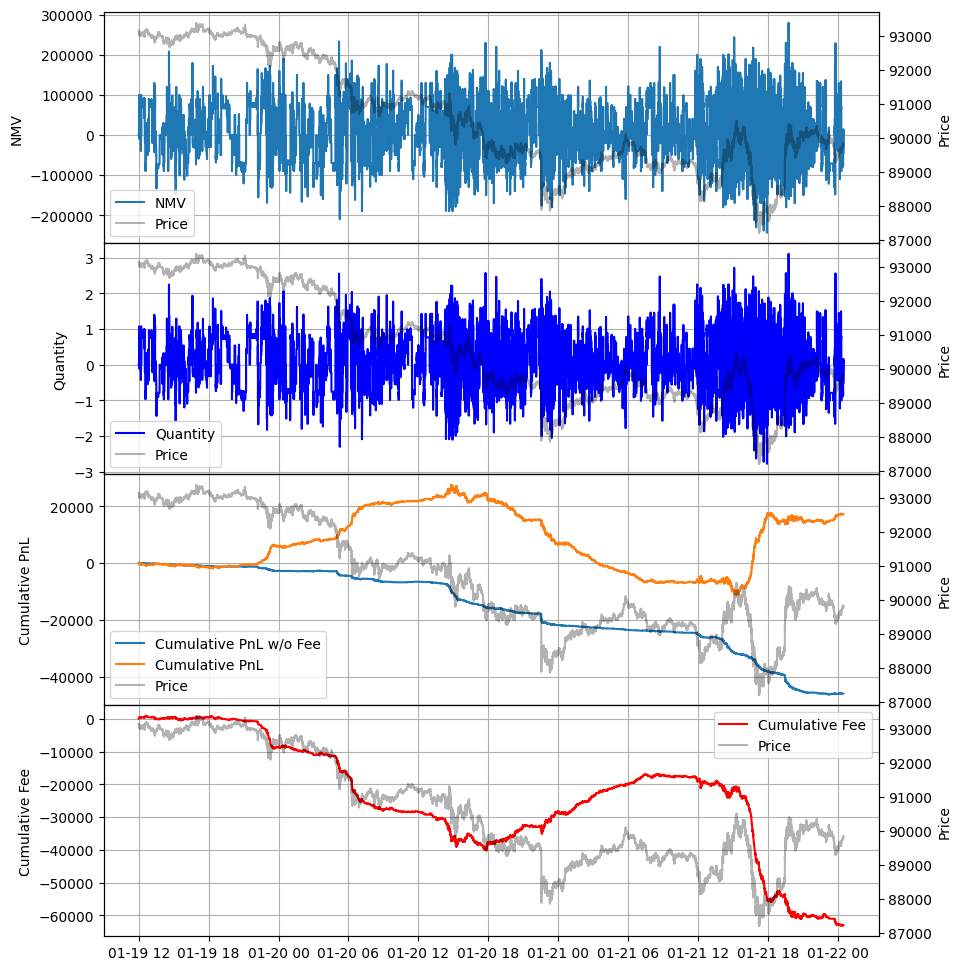

In [24]:
lgbm_listing_stats = lgbm_backtest.recorder.get_record(1).stats()
display(lgbm_listing_stats.summary())
lgbm_listing_stats.plot()

### LGBM model values & circuit breaker

,mid_price,inventory,realized_vol,predicted_vol_bps,optimal_bid,optimal_ask,reservation_price,best_bid,best_ask,bid_confidence,ask_confidence,circuit_breaker_active,spread
timestamp,,,,,,,,,,,,,
2026-01-19 12:00:16.281251008,93151.5,0.0,0.000004,0.041254,93150.581291,93152.418709,93151.5,93151.0,93152.0,0.1,0.1,0,1.0
2026-01-19 12:00:16.281251008,93151.5,0.0,0.000004,0.041254,93150.581291,93152.418709,93151.5,93151.0,93152.0,0.1,0.1,0,1.0
2026-01-19 12:00:16.281251008,93151.5,0.0,0.000004,0.041254,93150.581291,93152.418709,93151.5,93151.0,93152.0,0.1,0.1,0,1.0
2026-01-19 12:00:16.580715457,93151.5,0.0,0.000003,0.031191,93150.974825,93152.025175,93151.5,93151.0,93152.0,0.1,0.1,0,1.0
2026-01-19 12:00:17.080806604,93151.5,0.0,0.000004,0.037881,93150.725406,93152.274594,93151.5,93151.0,93152.0,0.1,0.1,0,1.0
2026-01-19 12:00:17.180717029,93151.5,0.0,0.000004,0.037881,93150.725406,93152.274594,93151.5,93151.0,93152.0,0.1,0.1,0,1.0
2026-01-19 12:00:17.680689331,93151.5,0.0,0.000004,0.037881,93150.725406,93152.274594,93151.5,93151.0,93152.0,0.1,0.1,0,1.0
2026-01-19 12:00:17.680719958,93151.5,0.0,0.000004,0.043291,93150.488356,93152.511644,93151.5,93151.0,93152.0,0.1,0.1,0,1.0
2026-01-19 12:00:18.280746720,93151.5,0.0,0.000003,0.033255,93150.903027,93152.096973,93151.5,93151.0,93152.0,0.1,0.1,0,1.0


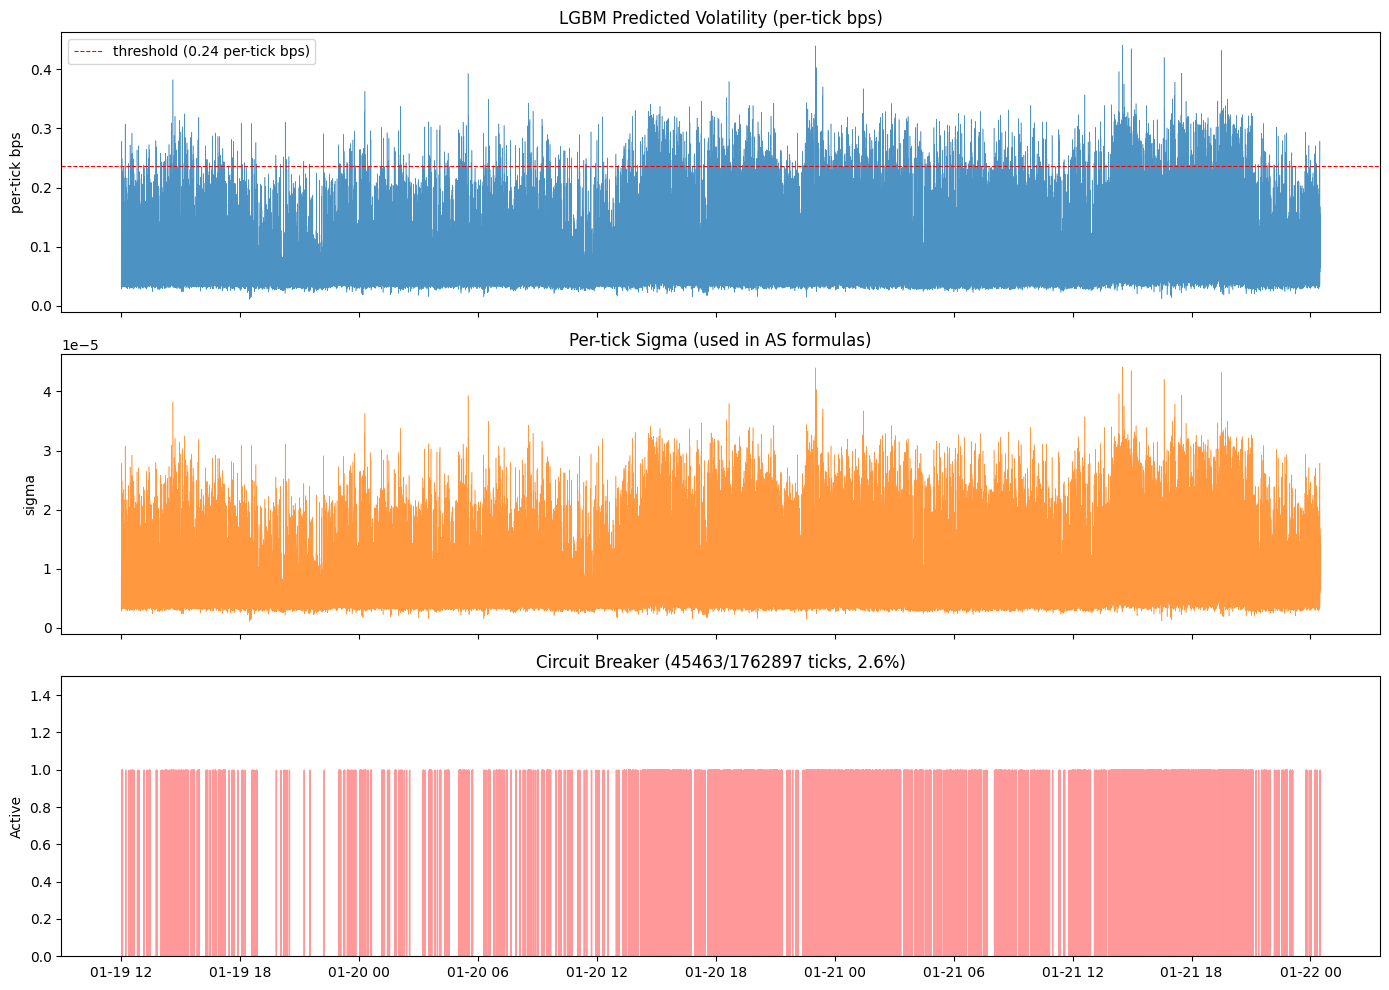

In [25]:
if lgbm_mm_signal.recorder is not None:
    lgbm_df = lgbm_mm_signal.recorder.get_record(listing.listing_id).df
    display(lgbm_df.head(20))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Predicted vol over time
    axes[0].plot(lgbm_df.index, lgbm_df['predicted_vol_bps'], linewidth=0.4, alpha=0.8)
    axes[0].axhline(CALIBRATED_MM_PARAMS['vol_threshold_bps'], color='red', ls='--', lw=0.8,
                     label=f"threshold ({CALIBRATED_MM_PARAMS['vol_threshold_bps']:.2f} per-tick bps)")
    axes[0].set_ylabel('per-tick bps')
    axes[0].set_title('LGBM Predicted Volatility (per-tick bps)')
    axes[0].legend()

    # Realized vol (per-tick sigma derived from model)
    axes[1].plot(lgbm_df.index, lgbm_df['realized_vol'], linewidth=0.4, alpha=0.8, color='tab:orange')
    axes[1].set_ylabel('sigma')
    axes[1].set_title('Per-tick Sigma (used in AS formulas)')

    # Circuit breaker timeline
    cb = lgbm_df['circuit_breaker_active'].astype(bool)
    cb_pct = cb.sum() / len(lgbm_df) * 100
    axes[2].fill_between(lgbm_df.index, 0, cb.astype(int), alpha=0.4, color='red')
    axes[2].set_ylabel('Active')
    axes[2].set_title(f'Circuit Breaker ({cb.sum()}/{len(lgbm_df)} ticks, {cb_pct:.1f}%)')
    axes[2].set_ylim(0, 1.5)

    plt.tight_layout()
    plt.show()

### RealizedVol vs LGBM comparison

,RealizedVol,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,...,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,6118.207757,-5680.935641,0.00747,455.881809,1.574481,2.207915,-1.076972,85.000683,...,2026-01-22 00:28:59.890919786,17157.440152,-63001.842527,0.00191,1001.783464,11.999479,8.2118,-0.272332,4744.506396,28554.0



Circuit breaker comparison:
  RealizedVol: 751/998867 ticks (0.1%)
  LGBM:        45463/1762897 ticks (2.6%)


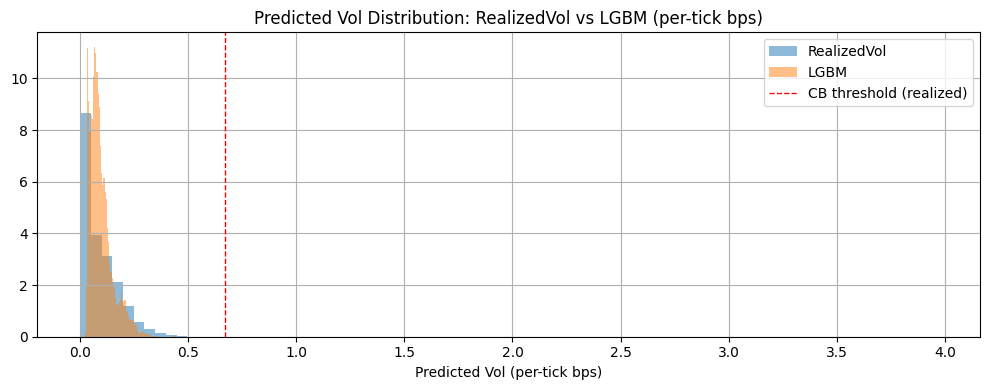

In [26]:
# Compare the two backtests side-by-side
realized_stats = backtest.recorder.get_record(LISTING_IDS[0]).stats()
lgbm_stats = lgbm_backtest.recorder.get_record(LISTING_IDS[0]).stats()

comparison = pd.concat([
    realized_stats.summary().rename(columns={realized_stats.summary().columns[0]: "RealizedVol"}),
    lgbm_stats.summary().rename(columns={lgbm_stats.summary().columns[0]: "LGBM"}),
], axis=1)
display(comparison)

# Compare recorder stats
rv_rec_df = basic_mm_signal.recorder.get_record(listing.listing_id).df
lgbm_rec_df = lgbm_mm_signal.recorder.get_record(listing.listing_id).df

rv_cb = rv_rec_df['circuit_breaker_active'].astype(bool)
lgbm_cb = lgbm_rec_df['circuit_breaker_active'].astype(bool)

print(f"\nCircuit breaker comparison:")
print(f"  RealizedVol: {rv_cb.sum()}/{len(rv_rec_df)} ticks ({rv_cb.mean()*100:.1f}%)")
print(f"  LGBM:        {lgbm_cb.sum()}/{len(lgbm_rec_df)} ticks ({lgbm_cb.mean()*100:.1f}%)")

# Overlay predicted vol distributions
fig, ax = plt.subplots(figsize=(10, 4))
rv_rec_df['predicted_vol_bps'].dropna().hist(ax=ax, bins=80, alpha=0.5, label='RealizedVol', density=True)
lgbm_rec_df['predicted_vol_bps'].dropna().hist(ax=ax, bins=80, alpha=0.5, label='LGBM', density=True)
ax.axvline(BASIC_MM_PARAMS['vol_threshold_bps'], color='red', ls='--', lw=1, label='CB threshold (realized)')
ax.set_xlabel('Predicted Vol (per-tick bps)')
ax.set_title('Predicted Vol Distribution: RealizedVol vs LGBM (per-tick bps)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Quote Quality Analysis

Post-backtest analysis of quoting quality for the RealizedVol backtest.

In [27]:
quality_stats = lgbm_stats
quality_recorder = lgbm_mm_signal.recorder
#quality_stats = listing_stats
#quality_recorder = basic_mm_signal.recorder

Total fills: 28554
  Buys:  13599
  Sells: 14955


,Mean (bps),Median (bps),Std (bps),Count
Horizon,,,,
T+5,-0.302,-0.057,0.972,28554
T+10,-0.461,-0.164,1.635,28554
T+20,-0.541,-0.278,2.594,28554
T+50,-0.624,-0.491,4.463,28554
T+100,-0.654,-0.601,6.435,28551


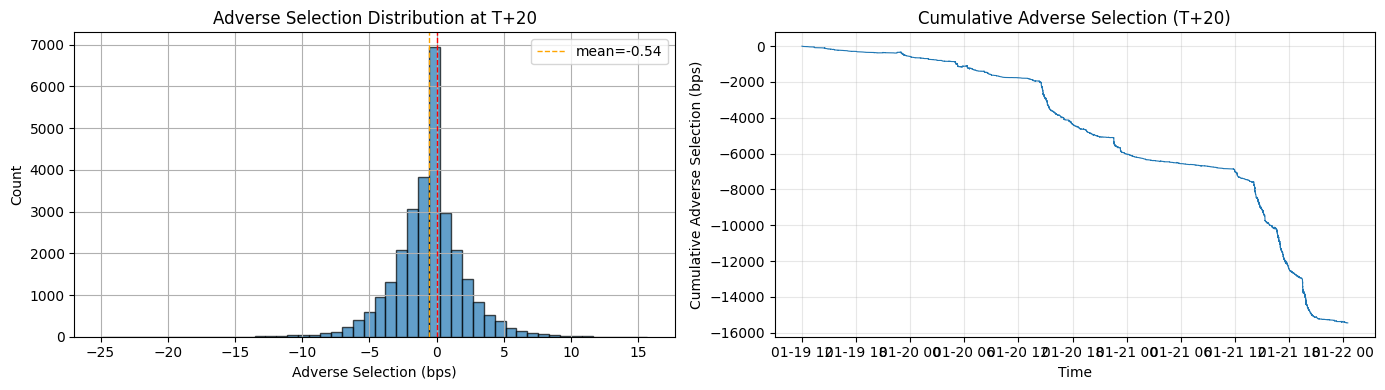

In [28]:
import matplotlib.pyplot as plt
from gnomepy.backtest.recorder import RecordType

# Adverse Selection Analysis
stats_data = quality_stats.data

# Compute quantity changes on full dataset
qty_change = stats_data['quantity'].diff().fillna(stats_data['quantity'].iloc[0])

# Separate fills and market events
is_fill = stats_data['event'] == RecordType.EXECUTION
fills = stats_data[is_fill].copy()
markets = stats_data[stats_data['event'] == RecordType.MARKET]

fills['qty_change'] = qty_change[is_fill].values
fills['side_sign'] = np.sign(fills['qty_change'])

print(f"Total fills: {len(fills)}")
print(f"  Buys:  {int((fills['side_sign'] > 0).sum())}")
print(f"  Sells: {int((fills['side_sign'] < 0).sum())}")

# Forward mid prices at various horizons via searchsorted
horizons = [5, 10, 20, 50, 100]
market_prices_arr = markets['price'].values
market_ts_arr = markets.index.values

fill_positions = np.searchsorted(market_ts_arr, fills.index.values, side='right')

adverse_data = {}
for n in horizons:
    fwd_idx = fill_positions + n
    valid = fwd_idx < len(market_prices_arr)
    fwd_prices = np.full(len(fills), np.nan)
    fwd_prices[valid] = market_prices_arr[fwd_idx[valid]]
    col = f'adverse_{n}'
    fills[col] = fills['side_sign'].values * (fwd_prices - fills['trade_price'].values) / fills['trade_price'].values * 1e4
    adverse_data[f'T+{n}'] = fills[col].dropna()

# Summary table
summary_rows = []
for label, series in adverse_data.items():
    summary_rows.append({
        'Horizon': label,
        'Mean (bps)': f"{series.mean():.3f}",
        'Median (bps)': f"{series.median():.3f}",
        'Std (bps)': f"{series.std():.3f}",
        'Count': len(series),
    })
display(pd.DataFrame(summary_rows).set_index('Horizon'))

# Histogram of adverse selection at T+20
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

adverse_20 = adverse_data['T+20']
adverse_20.hist(ax=axes[0], bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='red', ls='--', lw=1)
axes[0].axvline(adverse_20.mean(), color='orange', ls='--', lw=1,
                label=f"mean={adverse_20.mean():.2f}")
axes[0].set_xlabel('Adverse Selection (bps)')
axes[0].set_ylabel('Count')
axes[0].set_title('Adverse Selection Distribution at T+20')
axes[0].legend()

# Cumulative adverse selection over time
cum_adverse = adverse_20.cumsum()
axes[1].plot(cum_adverse.index, cum_adverse.values, linewidth=0.8)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Cumulative Adverse Selection (bps)')
axes[1].set_title('Cumulative Adverse Selection (T+20)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

PnL Decomposition:
  Spread capture (trade_pnl): $3,631.68
  Holding cost (holding_pnl): $-49,476.08
  Fees:                       $-63,001.84
  Net PnL:                    $17,157.44


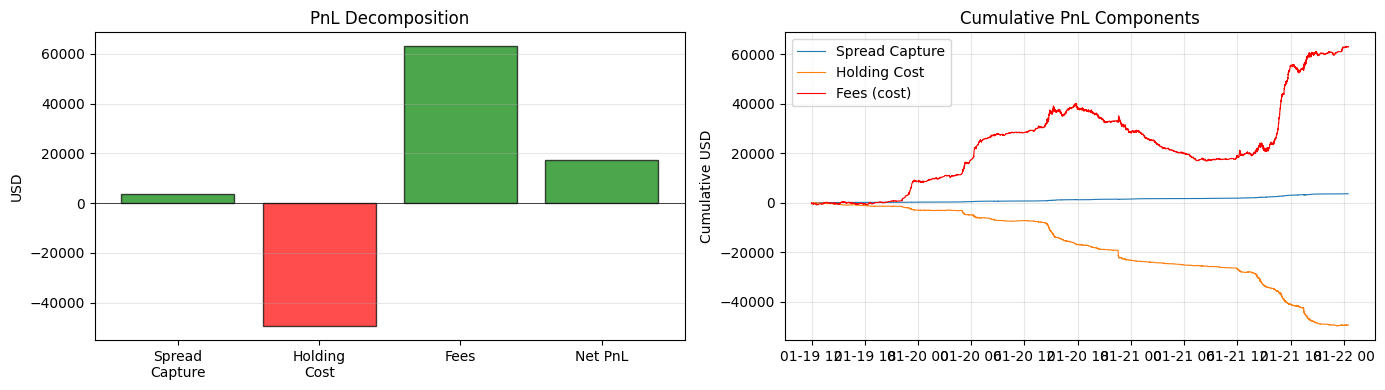

In [29]:
# PnL Decomposition
fills_data = quality_stats.data[quality_stats.data['event'] == RecordType.EXECUTION]

spread_capture = fills_data['trade_pnl'].sum()
holding_cost = quality_stats.data['holding_pnl'].sum()
fees = quality_stats.data['fee'].sum()
net_pnl = spread_capture + holding_cost - fees

print(f"PnL Decomposition:")
print(f"  Spread capture (trade_pnl): ${spread_capture:,.2f}")
print(f"  Holding cost (holding_pnl): ${holding_cost:,.2f}")
print(f"  Fees:                       ${fees:,.2f}")
print(f"  Net PnL:                    ${net_pnl:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
components = ['Spread\nCapture', 'Holding\nCost', 'Fees', 'Net PnL']
values = [spread_capture, holding_cost, -fees, net_pnl]
colors = ['green' if v >= 0 else 'red' for v in values]
axes[0].bar(components, values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('USD')
axes[0].set_title('PnL Decomposition')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].grid(axis='y', alpha=0.3)

# Cumulative time series
cum_spread = quality_stats.data['trade_pnl'].cumsum()
cum_holding = quality_stats.data['holding_pnl'].cumsum()
cum_fees = quality_stats.data['fee'].cumsum()

axes[1].plot(cum_spread.index, cum_spread.values, label='Spread Capture', linewidth=0.8)
axes[1].plot(cum_holding.index, cum_holding.values, label='Holding Cost', linewidth=0.8)
axes[1].plot(cum_fees.index, -cum_fees.values, label='Fees (cost)', linewidth=0.8, color='red')
axes[1].set_ylabel('Cumulative USD')
axes[1].set_title('Cumulative PnL Components')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Fill Rate & Quote Presence
signal_df = quality_recorder.get_record(listing.listing_id).df
total_ticks = len(signal_df)
cb_active = signal_df['circuit_breaker_active'].astype(bool)
cb_ticks = int(cb_active.sum())
cb_pct = cb_ticks / total_ticks * 100

fills_data = quality_stats.data[quality_stats.data['event'] == RecordType.EXECUTION]
qty_change = quality_stats.data['quantity'].diff().fillna(quality_stats.data['quantity'].iloc[0])
fill_qty_change = qty_change[quality_stats.data['event'] == RecordType.EXECUTION]
buys = int((fill_qty_change > 0).sum())
sells = int((fill_qty_change < 0).sum())

# Duration
start_ts = quality_stats.data.index.min()
end_ts = quality_stats.data.index.max()
duration_hours = (end_ts - start_ts).total_seconds() / 3600
fills_per_hour = len(fills_data) / duration_hours if duration_hours > 0 else 0

print(f"Quote Presence & Fill Rate:")
print(f"  Total ticks:       {total_ticks:,}")
print(f"  CB-active ticks:   {cb_ticks:,} ({cb_pct:.1f}%)")
print(f"  Quote presence:    {100 - cb_pct:.1f}%")
print(f"  Duration:          {duration_hours:.1f} hours")
print(f"  Total fills:       {len(fills_data):,}")
print(f"  Buys:              {buys}")
print(f"  Sells:             {sells}")
print(f"  Fills per hour:    {fills_per_hour:.1f}")

Quote Presence & Fill Rate:
  Total ticks:       1,762,897
  CB-active ticks:   45,463 (2.6%)
  Quote presence:    97.4%
  Duration:          60.5 hours
  Total fills:       28,554
  Buys:              13599
  Sells:             14955
  Fills per hour:    472.1


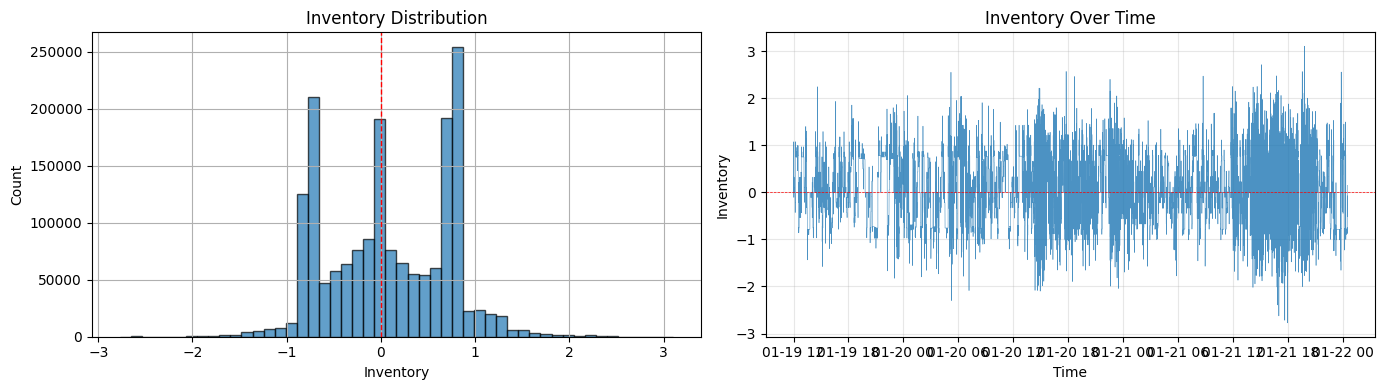

Inventory Stats:
  Mean absolute:  0.5505
  Max:            3.1048
  % at max (1.0): 6.3%


In [31]:
# Inventory Distribution
signal_df = quality_recorder.get_record(listing.listing_id).df
inventory = signal_df['inventory']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
inventory.hist(ax=axes[0], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Inventory')
axes[0].set_ylabel('Count')
axes[0].set_title('Inventory Distribution')
axes[0].axvline(0, color='red', ls='--', lw=1)

# Time series
axes[1].plot(signal_df.index, inventory.values, linewidth=0.4, alpha=0.8)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Inventory')
axes[1].set_title('Inventory Over Time')
axes[1].axhline(0, color='red', ls='--', lw=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

max_inv = BASIC_MM_PARAMS['max_inventory']
abs_inv = inventory.abs()
print(f"Inventory Stats:")
print(f"  Mean absolute:  {abs_inv.mean():.4f}")
print(f"  Max:            {abs_inv.max():.4f}")
print(f"  % at max ({max_inv}): {(abs_inv >= max_inv).mean() * 100:.1f}%")

Quoted vs Realized Spread:
  Median quoted full spread:    0.84 bps
  Median realized half-spread:  0.05 bps
  Mean quoted full spread:      1.41 bps
  Mean realized half-spread:    0.18 bps


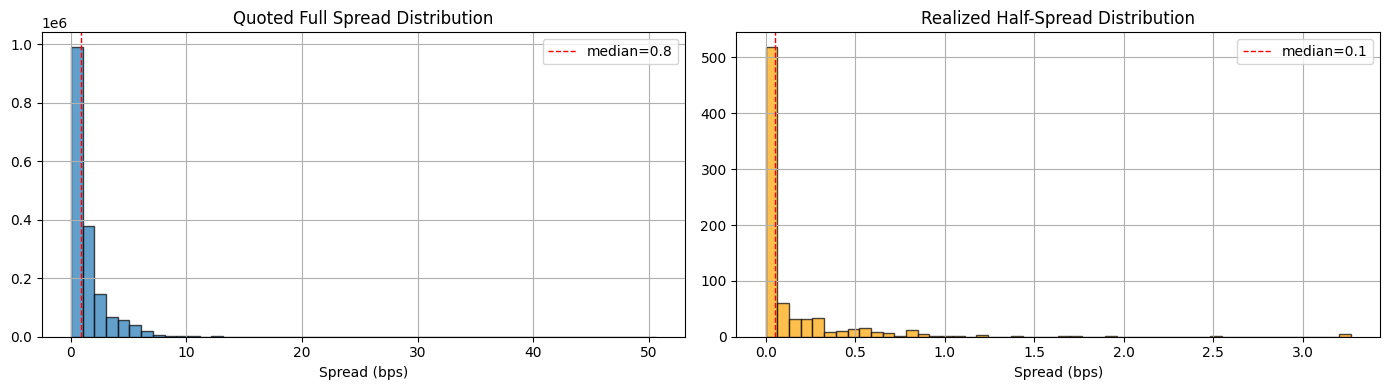

In [32]:
# Quoted vs Realized Spread
signal_df = quality_recorder.get_record(listing.listing_id).df
active = ~signal_df['circuit_breaker_active'].astype(bool)

# Quoted spread (during active quoting only)
quoted_spread = signal_df.loc[active, 'optimal_ask'] - signal_df.loc[active, 'optimal_bid']
quoted_spread_bps = quoted_spread / signal_df.loc[active, 'mid_price'] * 1e4

# Realized half-spread per fill
fills_data = listing_stats.data[listing_stats.data['event'] == RecordType.EXECUTION]
realized_half_spread = (fills_data['trade_price'] - fills_data['price']).abs()
realized_half_spread_bps = realized_half_spread / fills_data['price'] * 1e4

print(f"Quoted vs Realized Spread:")
print(f"  Median quoted full spread:    {quoted_spread_bps.median():.2f} bps")
print(f"  Median realized half-spread:  {realized_half_spread_bps.median():.2f} bps")
print(f"  Mean quoted full spread:      {quoted_spread_bps.mean():.2f} bps")
print(f"  Mean realized half-spread:    {realized_half_spread_bps.mean():.2f} bps")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

quoted_spread_bps.hist(ax=axes[0], bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(quoted_spread_bps.median(), color='red', ls='--', lw=1,
                label=f'median={quoted_spread_bps.median():.1f}')
axes[0].set_xlabel('Spread (bps)')
axes[0].set_title('Quoted Full Spread Distribution')
axes[0].legend()

realized_half_spread_bps.hist(ax=axes[1], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].axvline(realized_half_spread_bps.median(), color='red', ls='--', lw=1,
                label=f'median={realized_half_spread_bps.median():.1f}')
axes[1].set_xlabel('Spread (bps)')
axes[1].set_title('Realized Half-Spread Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

Quote Position vs BBO (1,717,434 active ticks)

                         Improving        At BBO    Behind BBO
                 Bid   428,303 (24.9%)         0 ( 0.0%)  1,289,131 (75.1%)
                 Ask   599,497 (34.9%)         0 ( 0.0%)  1,117,937 (65.1%)

Both sides at or inside BBO: 24,644 (1.4%)

Bid distance from BBO (bps):  mean=-0.695  median=-0.263  std=1.454
Ask distance from BBO (bps):  mean=-0.483  median=-0.149  std=1.137
Market spread (bps):          mean=0.236  median=0.111


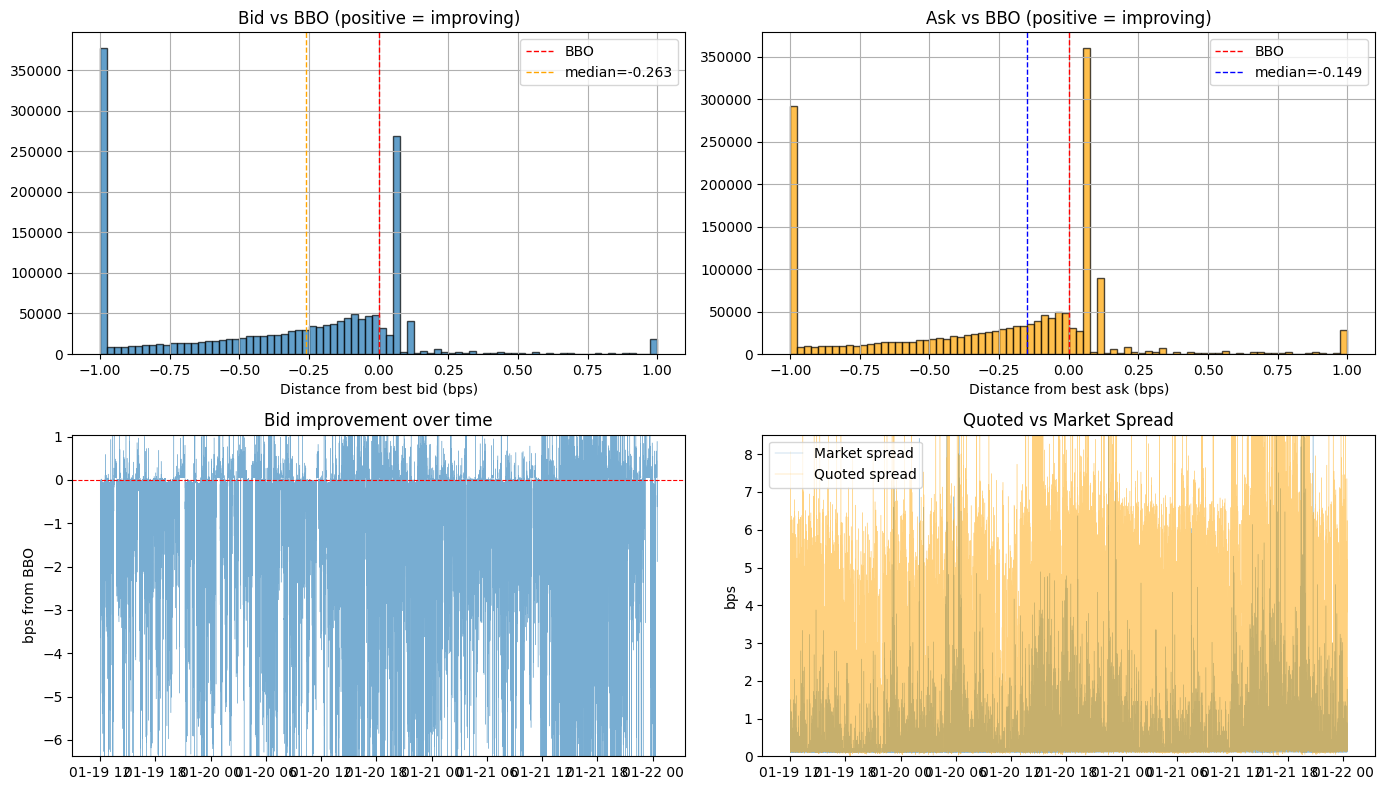

In [33]:
# Bid/Ask vs Best Bid/Ask (BBO) Analysis
signal_df = quality_recorder.get_record(listing.listing_id).df
active = ~signal_df['circuit_breaker_active'].astype(bool)
df_active = signal_df[active].copy()

mid = df_active['mid_price']
best_bid = df_active['best_bid']
best_ask = df_active['best_ask']
opt_bid = df_active['optimal_bid']
opt_ask = df_active['optimal_ask']
market_spread_bps = (best_ask - best_bid) / mid * 1e4

# Distance from BBO in bps (positive = improving, negative = behind)
bid_vs_bbo_bps = (opt_bid - best_bid) / mid * 1e4
ask_vs_bbo_bps = (best_ask - opt_ask) / mid * 1e4  # flipped so positive = improving

# Classification
bid_improving = (opt_bid > best_bid).sum()
bid_at_bbo = ((opt_bid == best_bid)).sum()
bid_behind = (opt_bid < best_bid).sum()

ask_improving = (opt_ask < best_ask).sum()
ask_at_bbo = ((opt_ask == best_ask)).sum()
ask_behind = (opt_ask > best_ask).sum()

n = len(df_active)
print(f"Quote Position vs BBO ({n:,} active ticks)\n")
print(f"{'':>20s}  {'Improving':>12s}  {'At BBO':>12s}  {'Behind BBO':>12s}")
print(f"{'Bid':>20s}  {bid_improving:>8,} ({bid_improving/n*100:4.1f}%)  {bid_at_bbo:>8,} ({bid_at_bbo/n*100:4.1f}%)  {bid_behind:>8,} ({bid_behind/n*100:4.1f}%)")
print(f"{'Ask':>20s}  {ask_improving:>8,} ({ask_improving/n*100:4.1f}%)  {ask_at_bbo:>8,} ({ask_at_bbo/n*100:4.1f}%)  {ask_behind:>8,} ({ask_behind/n*100:4.1f}%)")

both_competitive = ((opt_bid >= best_bid) & (opt_ask <= best_ask)).sum()
print(f"\nBoth sides at or inside BBO: {both_competitive:,} ({both_competitive/n*100:.1f}%)")

# Distance statistics
print(f"\nBid distance from BBO (bps):  mean={bid_vs_bbo_bps.mean():.3f}  median={bid_vs_bbo_bps.median():.3f}  std={bid_vs_bbo_bps.std():.3f}")
print(f"Ask distance from BBO (bps):  mean={ask_vs_bbo_bps.mean():.3f}  median={ask_vs_bbo_bps.median():.3f}  std={ask_vs_bbo_bps.std():.3f}")
print(f"Market spread (bps):          mean={market_spread_bps.mean():.3f}  median={market_spread_bps.median():.3f}")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Bid distance from BBO
bid_vs_bbo_bps.clip(-1, 1).hist(ax=axes[0, 0], bins=80, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='red', ls='--', lw=1, label='BBO')
axes[0, 0].axvline(bid_vs_bbo_bps.median(), color='orange', ls='--', lw=1,
                    label=f'median={bid_vs_bbo_bps.median():.3f}')
axes[0, 0].set_xlabel('Distance from best bid (bps)')
axes[0, 0].set_title('Bid vs BBO (positive = improving)')
axes[0, 0].legend()

# Ask distance from BBO
ask_vs_bbo_bps.clip(-1, 1).hist(ax=axes[0, 1], bins=80, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].axvline(0, color='red', ls='--', lw=1, label='BBO')
axes[0, 1].axvline(ask_vs_bbo_bps.median(), color='blue', ls='--', lw=1,
                    label=f'median={ask_vs_bbo_bps.median():.3f}')
axes[0, 1].set_xlabel('Distance from best ask (bps)')
axes[0, 1].set_title('Ask vs BBO (positive = improving)')
axes[0, 1].legend()

# Time series of bid improvement
axes[1, 0].plot(df_active.index, bid_vs_bbo_bps.values, linewidth=0.3, alpha=0.6)
axes[1, 0].axhline(0, color='red', ls='--', lw=0.8)
axes[1, 0].set_ylabel('bps from BBO')
axes[1, 0].set_title('Bid improvement over time')
axes[1, 0].set_ylim(bid_vs_bbo_bps.quantile(0.01), bid_vs_bbo_bps.quantile(0.99))

# Quoted spread vs market spread over time
quoted_spread_bps = (opt_ask - opt_bid) / mid * 1e4
axes[1, 1].plot(df_active.index, market_spread_bps.values, linewidth=0.3, alpha=0.5, label='Market spread')
axes[1, 1].plot(df_active.index, quoted_spread_bps.values, linewidth=0.3, alpha=0.5, label='Quoted spread', color='orange')
axes[1, 1].set_ylabel('bps')
axes[1, 1].set_title('Quoted vs Market Spread')
axes[1, 1].legend()
axes[1, 1].set_ylim(0, max(market_spread_bps.quantile(0.99), quoted_spread_bps.quantile(0.99)) * 1.2)

plt.tight_layout()
plt.show()

42300.0